# III. PHẦN 2 – VOLATILITY CLUSTERING

Phân tích chuỗi log-return hằng ngày của XOM để quan sát các giai đoạn biến động thấp, biến động cao và dấu hiệu volatility clustering.

In [1]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib-cache"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/XOM_SP500_2024_2026.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Số quan sát:", len(df))
print("Giai đoạn:", df["Date"].min().date(), "đến", df["Date"].max().date())
df.head()

Số quan sát: 686
Giai đoạn: 2024-01-03 đến 2026-09-28


,Date,XOM,SP500,XOM_Return,SP500_Return
0,2024-01-03,94.388016,4704.810059,0.008367,-0.008049
1,2024-01-04,93.565025,4688.680176,-0.008757,-0.003434
2,2024-01-05,93.848495,4697.240234,0.003025,0.001824
3,2024-01-08,92.284821,4763.540039,-0.016802,0.014016
4,2024-01-09,91.141769,4756.500000,-0.012463,-0.001479


## 3.1. Time Series Visualization

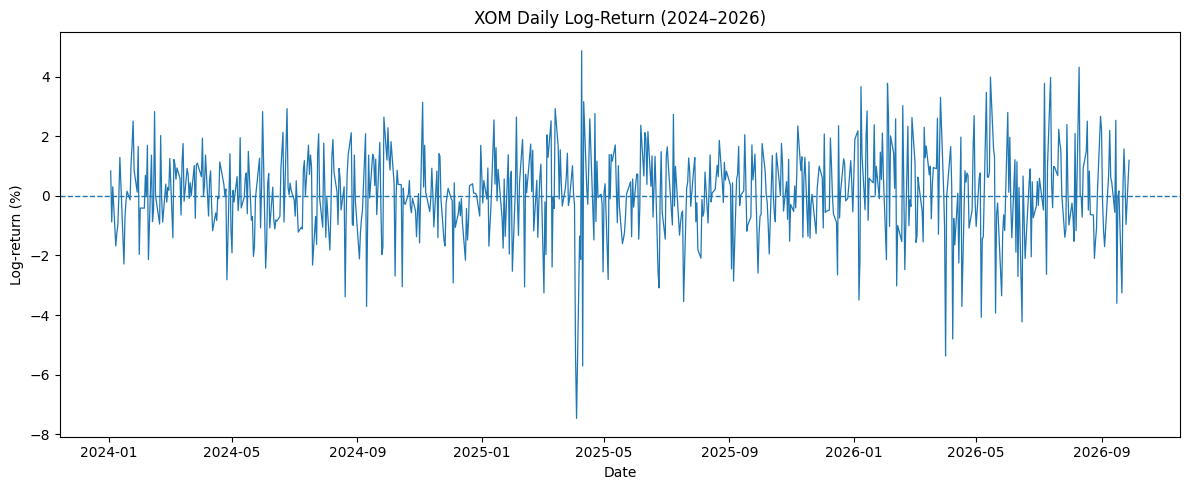

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["XOM_Return"] * 100, linewidth=0.9)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("XOM Daily Log-Return (2024–2026)")
plt.xlabel("Date")
plt.ylabel("Log-return (%)")
plt.tight_layout()
plt.show()

## 3.2. Nhận diện Volatility Clustering

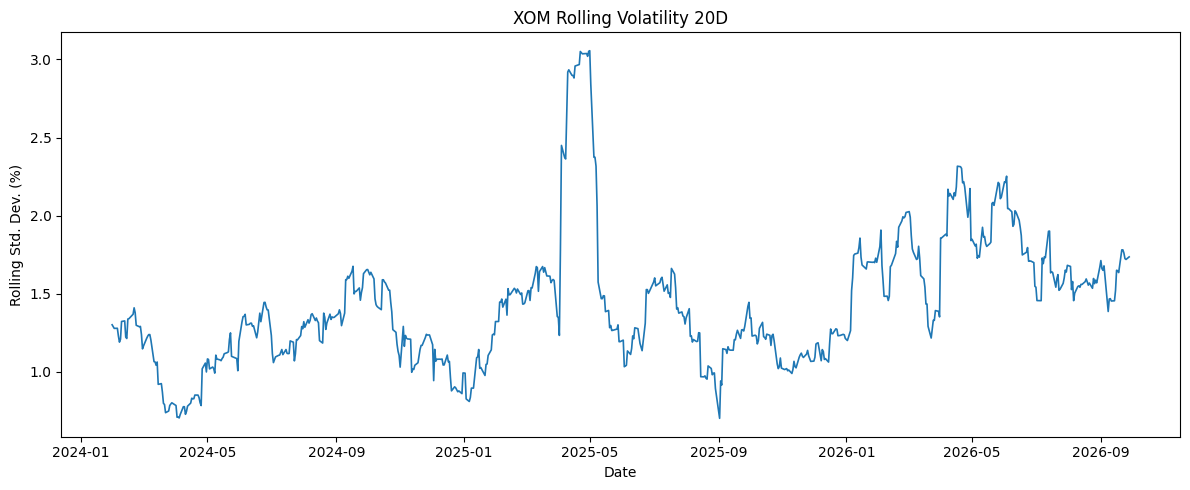

In [3]:
# Rolling volatility 20 ngày để hỗ trợ nhận diện các cụm biến động
df["Rolling_Vol_20D"] = df["XOM_Return"].rolling(20).std() * 100

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Rolling_Vol_20D"], linewidth=1.2)
plt.title("XOM Rolling Volatility 20D")
plt.xlabel("Date")
plt.ylabel("Rolling Std. Dev. (%)")
plt.tight_layout()
plt.show()

In [4]:
# Thống kê volatility theo tháng để xác định các giai đoạn nổi bật
monthly_vol = (
    df.assign(Month=df["Date"].dt.to_period("M"))
      .groupby("Month")["XOM_Return"]
      .std()
      .mul(100)
      .sort_values(ascending=False)
)

print("Các tháng có volatility cao nhất:")
display(monthly_vol.head(8).to_frame("Monthly Std. Dev. (%)"))

print("\nCác tháng có volatility thấp nhất:")
display(monthly_vol.tail(8).sort_values().to_frame("Monthly Std. Dev. (%)"))

Các tháng có volatility cao nhất:


,Monthly Std. Dev. (%)
Month,
2025-04,2.978687
2026-05,2.119588
2026-04,2.119473
2026-02,2.075882
2026-01,1.702047
2026-09,1.679612
2026-06,1.666265
2024-09,1.654838



Các tháng có volatility thấp nhất:


,Monthly Std. Dev. (%)
Month,
2024-03,0.802799
2024-12,0.971828
2025-08,0.980732
2025-10,1.041136
2024-04,1.048225
2025-11,1.092935
2024-02,1.148012
2025-05,1.165202


In [5]:
# Các ngày XOM có biến động tuyệt đối lớn nhất
top_moves = (
    df.assign(
        XOM_Return_pct=df["XOM_Return"] * 100,
        SP500_Return_pct=df["SP500_Return"] * 100,
        Abs_XOM_Return=(df["XOM_Return"] * 100).abs()
    )
    .nlargest(12, "Abs_XOM_Return")
    [["Date", "XOM_Return_pct", "SP500_Return_pct"]]
)

display(top_moves.style.format({
    "XOM_Return_pct": "{:.2f}%",
    "SP500_Return_pct": "{:.2f}%"
}))

,Date,XOM_Return_pct,SP500_Return_pct
314,2025-04-04 00:00:00,-7.47%,-6.16%
318,2025-04-10 00:00:00,-5.71%,-3.52%
313,2025-04-03 00:00:00,-5.40%,-4.96%
562,2026-04-01 00:00:00,-5.38%,0.71%
317,2025-04-09 00:00:00,4.87%,9.09%
566,2026-04-08 00:00:00,-4.81%,2.48%
651,2026-08-10 00:00:00,4.32%,-0.06%
613,2026-06-15 00:00:00,-4.23%,1.64%
586,2026-05-06 00:00:00,-4.08%,1.45%
593,2026-05-15 00:00:00,3.99%,-1.24%


## 3.3. Liên hệ với thị trường

Đối chiếu các giai đoạn volatility cao với biến động của thị trường năng lượng và S&P 500.  
**Lưu ý:** việc trùng thời điểm chỉ cho thấy mối liên hệ về thời gian, không đủ để kết luận quan hệ nhân quả.

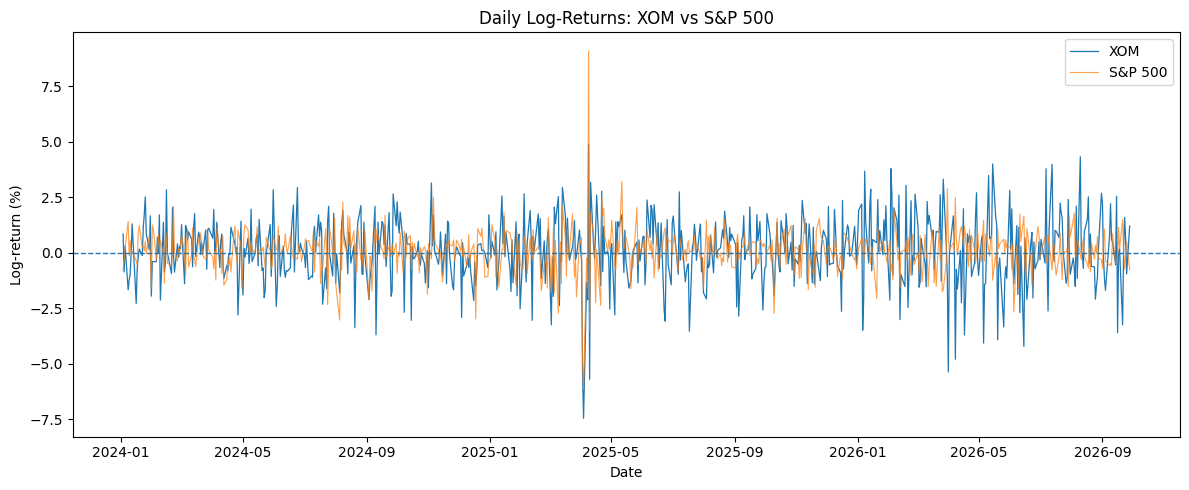

In [6]:
# So sánh XOM và S&P 500 trong các giai đoạn biến động lớn
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Date"], df["XOM_Return"] * 100, label="XOM", linewidth=0.9)
ax.plot(df["Date"], df["SP500_Return"] * 100, label="S&P 500", linewidth=0.8, alpha=0.75)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Daily Log-Returns: XOM vs S&P 500")
ax.set_xlabel("Date")
ax.set_ylabel("Log-return (%)")
ax.legend()
plt.tight_layout()
plt.show()

## 3.4. Kết luận Phần 2

Biểu đồ chuỗi thời gian cho thấy các giai đoạn biến động lớn có xu hướng xuất hiện gần nhau, xen kẽ với các giai đoạn tương đối ổn định. Đây là dấu hiệu trực quan của **volatility clustering** và là cơ sở để tiếp tục kiểm tra ARCH effect và mô hình hóa **conditional volatility** bằng GARCH ở Phần 3.